# Notebook #1:</br> Data Wrangling and Feature Engineering
#### by Sebastian Einar Salas Røkholt
---

**Notebook Index**
- [**1 - Introduction and Notebook Setup**](#1---introduction-and-notebook-setup)
  - [*1.1 Setup*](#11-setup)
  - [*1.2 Explanation of variables in the dataset*](#12-explanation-of-variables-in-the-dataset)

- [**2 - Data Wrangling**](#2---data-wrangling)
  - [*2.1 Identifying and handling missing data*](#21-identifying-and-handling-missing-data)
    - [*2.1.1 Handling power output readings of 0*](#211-handling-power-output-readings-of-0)
    - [*2.1.2 Enforcing a consistent sampling rate*](#212-enforcing-a-consistent-sampling-rate)
      - [*2.1.2.1 Identify discrepancies between expected and actual sample counts*](#2121-identify-discrepancies-between-expected-and-actual-sample-counts)
      - [*2.1.2.2 Handling missing and extra readings*](#2122-handling-missing-and-extra-readings)
  - [*2.2 Removing unusually short and long sessions*](#22-removing-unusually-short-and-long-sessions)

- [**3 - Feature Engineering**](#3---feature-engineering)
  - [*3.1 Adding a progress feature (log-scaled duration)*](#31-adding-a-progress-feature-log-scaled-duration)
  - [*3.2 Relative power*](#32-relative-power)
  - [*3.3 Adding deltas: change in power and SOC over time*](#33-adding-deltas-change-in-power-and-soc-over-time)
  - [*3.4 EMA per session*](#34-ema-per-session)
  - [*3.5 One-hot encoding of charger category*](#35-one-hot-encoding-of-charger-category)
  - [*3.6 Taper regime features*](#36-taper-regime-features)
  - [*3.7 Wrap-up and save dataset*](#37-wrap-up-and-save-dataset)

---

## 1 - Introduction and Notebook Setup

In this notebook, the anonymised public charging-session dataset from Notebook #0 is cleaned and transformed into a modelling-ready table. The pipeline keeps non-sensitive wrangling and feature engineering steps while using only public attributes.

### 1.1 Setup
This section initializes the computational environment by importing the required Python libraries, configuring the runtime environment and notebook settings, and defining the global constants used across the notebook.

To generate an API key for the Frost and DMI APIs, see the resources below. Both are free of charge. </br>
 - [Create a Frost user](https://frost.met.no/auth/requestCredentials.html)
 - [Register a DMI user and appliaction](https://opendatadocs.dmi.govcloud.dk/Authentication)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
RAW_PUBLIC_PARQUET = "../Data/etron55-charging-sessions-public.parquet"
OUT_PARQUET = "../Data/etron55-charging-sessions-public-processed.parquet"

# Configures the notebook's Pandas display settings
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

The dataset is a multivariate time series organised by electric vehicle (EV) charging sessions, where each session has a unique `charging_id`. The public base dataset already includes `minutes_elapsed` and `temp`, while sensitive fields were removed during anonymisation. This notebook applies non-sensitive wrangling and feature engineering for downstream modelling.

In [2]:
# Loads the anonymised public dataset
columns = [
    "charging_id", "minutes_elapsed",
    "power", "soc", "energy",
    "charging_duration",
    "charger_category", "nominal_power",
    "temp",
]
df = pd.read_parquet(RAW_PUBLIC_PARQUET, columns=columns)
print(f"Rows loaded: {len(df):,}")
print(f"Sessions loaded: {df['charging_id'].nunique():,}")

Rows loaded: 1,643,654
Sessions loaded: 62,422


#### Explanation of variables in the dataset
The public base dataset contains anonymised EV charging sessions and excludes all location identifiers and precise timestamps.
 - **`charging_id`, categorical, static (per session):** Identifier for one charging session.
 - **`minutes_elapsed`, numerical, monotonic, time-dependent:** Minutes since session start.
 - **`power`, numerical, piecewise continuous, time-dependent:** Charging power in kW.
 - **`soc`, numerical, piecewise continuous, time-dependent:** Battery state of charge in percent.
 - **`energy`, numerical, piecewise continuous, time-dependent:** Delivered session energy in kWh.
 - **`charging_duration`, numerical, discrete, static (per session):** Provider-reported session duration in minutes.
 - **`charger_category`, categorical, static (per session):** Charger category label.
 - **`nominal_power`, ordinal, static (per session):** Charger nameplate power in kW.
 - **`temp`, numerical, discrete, static (per session):** Session-level ambient temperature estimate.

----
## 2 - Data Wrangling
First, we will adresss any structural issues such as invalid values, zero-power runs, inconsistent sampling
(missing or extra readings), and implausibly short/long sessions.

In [3]:
# Displays the dataset's size, columns, number of missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1643654 entries, 0 to 1643653
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype   
---  ------             --------------    -----   
 0   charging_id        1643654 non-null  int64   
 1   minutes_elapsed    1643654 non-null  int64   
 2   power              1643654 non-null  float64 
 3   soc                1643654 non-null  float64 
 4   energy             1643654 non-null  float64 
 5   charging_duration  1643654 non-null  int64   
 6   charger_category   1643654 non-null  category
 7   nominal_power      1643654 non-null  int64   
 8   temp               1643654 non-null  int64   
dtypes: category(1), float64(3), int64(5)
memory usage: 101.9 MB


The dataset does not contain any invalid values, such as `np.nan`, `pd.NA`, `pd.NAT`, and `None`.

In [4]:
# Sets appropriate data types
df["nominal_power"] = df["nominal_power"].astype(int)
df["charger_category"] = df["charger_category"].astype("category")
df["minutes_elapsed"] = df["minutes_elapsed"].astype(int)

# Ensures minute-indexed ordering per session
df = df.sort_values(by=["charging_id", "minutes_elapsed"]).reset_index(drop=True)

In [5]:
print("Number of charging sessions: ", len(pd.unique(df["charging_id"])))

Number of charging sessions:  62422


### 2.1 Identifying and handling missing data
Even though the dataset doesn't contain any missing data in terms of invalid values, but there might be other types of missing data. If we look at the dataset as a collection of charging sessions (identified by `charging_id`), we see that there are: 
 - Power readings that are `0`
 - Readings at timestamps we would expect to be present, but aren't due to a inconsistent sampling rate

#### 2.1.1 Handling power output readings of `0`
We define a reading of `0` kW to be a missing value when it occurs at the beginning or the end of a charging session. These zero readings occur because the charging station starts recording data from the session before any power is delivered to the vehicle, and immediately after the the charger is disconnected. We trim these leading and trailing zeros from the dataset, as they do not contain any valid information about the normality of the charging session, and thus might introduce unwanted noise to the training data.

In [6]:
# Calculates and displays the number of rows where the power output is zero
rows_with_zeros = df[df["power"] == 0]
print(f"There are {len(rows_with_zeros)} rows where the power output is zero.")

There are 34500 rows where the power output is zero.


In [7]:
zeros_indices = rows_with_zeros.head().index  # Selects the index of five of these rows
print("First five rows with 0 in 'power' and their neighbors:\n")
for idx in zeros_indices:
    # Get two preceding and two succeeding rows
    start = max(0, idx - 2)
    end = min(len(df), idx + 3)
    neighbors = df.iloc[start:end]
    print(f"--- Rows around index {idx} ---")
    display(neighbors)

First five rows with 0 in 'power' and their neighbors:

--- Rows around index 82 ---


,charging_id,minutes_elapsed,power,soc,energy,charging_duration,charger_category,nominal_power,temp
80,9323,37,41.77,98.0,57.16,40,Ultra,150,4
81,9323,38,34.05,98.0,57.76,40,Ultra,150,4
82,9323,39,0.00,100.0,58.26,40,Ultra,150,4
83,11921,0,94.05,39.0,0.23,21,Rapid,100,5
84,11921,1,98.70,41.0,1.86,21,Rapid,100,5


--- Rows around index 141 ---


,charging_id,minutes_elapsed,power,soc,energy,charging_duration,charger_category,nominal_power,temp
139,17906,35,95.94,77.0,55.31,38,Ultra,150,6
140,17906,36,95.94,79.0,56.91,38,Ultra,150,6
141,17906,37,0.00,80.0,57.25,38,Ultra,150,6
142,29836,0,89.13,15.0,0.22,34,Ultra,150,-1
143,29836,1,93.92,17.0,1.76,34,Ultra,150,-1


--- Rows around index 249 ---


,charging_id,minutes_elapsed,power,soc,energy,charging_duration,charger_category,nominal_power,temp
247,39929,21,96.64,83.0,36.90,23,Ultra,150,-3
248,39929,22,91.07,85.0,38.46,23,Ultra,150,-3
249,40043,0,0.00,16.0,0.00,17,Rapid,50,0
250,40043,1,48.98,17.0,0.67,17,Rapid,50,0
251,40043,2,48.31,18.0,1.48,17,Rapid,50,0


--- Rows around index 384 ---


,charging_id,minutes_elapsed,power,soc,energy,charging_duration,charger_category,nominal_power,temp
382,53363,29,47.60,98.0,45.97,32,Ultra,150,4
383,53363,30,35.07,98.0,46.71,32,Ultra,150,4
384,53363,31,0.00,100.0,47.17,32,Ultra,150,4
385,54941,0,101.34,37.0,0.28,33,Ultra,150,0
386,54941,1,106.14,40.0,2.01,33,Ultra,150,0


--- Rows around index 449 ---


,charging_id,minutes_elapsed,power,soc,energy,charging_duration,charger_category,nominal_power,temp
447,59415,17,86.66,78.0,25.12,19,Ultra,150,3
448,59415,18,86.75,79.0,26.56,19,Ultra,150,3
449,59991,0,0.00,23.0,0.00,24,Rapid,50,4
450,59991,1,49.20,24.0,0.68,24,Rapid,50,4
451,59991,2,49.32,25.0,1.51,24,Rapid,50,4


In [8]:
def trim_zeros_from_power_output(data: pd.DataFrame) -> pd.DataFrame:
    """Trim leading and trailing zero-power rows within each session.
    
    Parameters
    ----------
    data : pd.DataFrame
        Long time-series table with at least columns: charging_id, power.
    
    Returns
    -------
    pd.DataFrame
        Same schema, with edge zeros dropped per session.
    """
    to_drop = []
    for _, g in data.groupby("charging_id"):
        vals = g["power"].values
        idx = g.index.values
        first_nonzero = next((i for i, v in enumerate(vals) if v != 0), None)
        last_nonzero = next((i for i, v in enumerate(vals[::-1]) if v != 0), None)
        if first_nonzero is None:
            # All zeros → drop whole group
            to_drop.extend(idx.tolist())
            continue
        keep = idx[first_nonzero: len(idx) - last_nonzero] if last_nonzero is not None else idx[first_nonzero:]
        drop = list(set(idx) - set(keep))
        to_drop.extend(drop)
    return data.drop(to_drop)

# Trims leading and trailing zero-power rows from the dataset
before_n = len(df)
df = trim_zeros_from_power_output(df)
print(f"Trimmed {before_n - len(df)} leading/trailing zero-power rows.")

Trimmed 33896 leading/trailing zero-power rows.


It seems that most of these zero outputs occur at the beginning (leading) or at the end (trailing) of the charging session. These zeros can be removed, but if there are zeros in the middle of a session, we want to keep them as they might be an indicator of a problem with the vehicle's battery or the charger.

In [9]:
remaining_zeros = len(df[df["power"]==0])
print(f"There are still {remaining_zeros} rows left where the power output is zero, but these values are not leading or trailing.")
df = df.copy()

There are still 604 rows left where the power output is zero, but these values are not leading or trailing.


#### 2.1.2 Enforcing a consistent sampling rate

We ensure consistent data quality by verifying a one-reading-per-minute cadence using the integer minute index. Grouping by `charging_id`, we calculate the actual and expected number of readings for each session, identify missing or duplicate minute positions, and compare expected length to the provider-reported `charging_duration`.

The following code performs these steps by:
1. Grouping data by charging_id to calculate session-level minute bounds and reading counts.
2. Computing expected readings from the minute index and comparing against actual readings.
3. Identifying discrepancies in reading counts and mismatches in reported durations.

In [10]:
def calculate_session_stats(data: pd.DataFrame) -> pd.DataFrame:
    """Computes session-level sampling statistics from minute indices.

    Args:
        data: Long time-series table containing `charging_id` and `minutes_elapsed`.

    Returns:
        Session-level table with expected and actual readings, missing counts,
        missing percentage, and duration mismatch flag.
    """
    session_stats = (
        data.groupby("charging_id", observed=False)
        .agg(
            first_minute=("minutes_elapsed", "min"),
            last_minute=("minutes_elapsed", "max"),
            actual_readings=("minutes_elapsed", "count"),
            charging_duration=("charging_duration", "first"),
        )
        .reset_index()
    )

    session_stats["expected_readings"] = (
        session_stats["last_minute"] - session_stats["first_minute"] + 1
    ).astype(int)
    session_stats["n_missing_readings"] = (
        session_stats["expected_readings"] - session_stats["actual_readings"]
    )
    session_stats["extra_or_missing_percentage"] = (
        session_stats["n_missing_readings"] / session_stats["expected_readings"]
    ) * 100.0
    session_stats["duration_mismatch"] = (
        session_stats["expected_readings"] != session_stats["charging_duration"]
    )
    return session_stats

session_stats = calculate_session_stats(df)
print("Calculated session-level sampling statistics.")
print(session_stats[["expected_readings", "actual_readings", "n_missing_readings"]].describe())

Calculated session-level sampling statistics.
       expected_readings  actual_readings  n_missing_readings
count       62393.000000     62393.000000        62393.000000
mean           25.659064        25.800298           -0.141234
std            12.242622        12.837438            3.274213
min             1.000000         1.000000         -207.000000
25%            17.000000        17.000000            0.000000
50%            23.000000        23.000000            0.000000
75%            32.000000        32.000000            0.000000
max           161.000000       312.000000          106.000000


In [11]:
print(f"Total number of charging sessions: {len(session_stats)}")
mismatched_sessions_count = session_stats['duration_mismatch'].sum()
print(f"Number of charging sessions with duration mismatch: {mismatched_sessions_count}")
sessions_with_missing_readings = session_stats[session_stats["n_missing_readings"] > 0]
sessions_with_extra_readings = session_stats[session_stats["n_missing_readings"] < 0]
print(f"Number of charging sessions with missing readings: {len(sessions_with_missing_readings)}")
print(f"Number of charging sessions with extra readings: {len(sessions_with_extra_readings)}")

Total number of charging sessions: 62393
Number of charging sessions with duration mismatch: 6245
Number of charging sessions with missing readings: 454
Number of charging sessions with extra readings: 924


We see that there is a large number (960) of charging sessions that have extra readings, while a smaller but significant portion (438) have missing readings. We will investigate this issue further by plotting the distribution of the number of extra and missing values. 

##### 2.1.2.1 Identify discrepancies between expected and actual sample counts
We visualize the distribution (log-y) of extra/missing readings per session, with the long tail
bucketed to keep the main part readable.

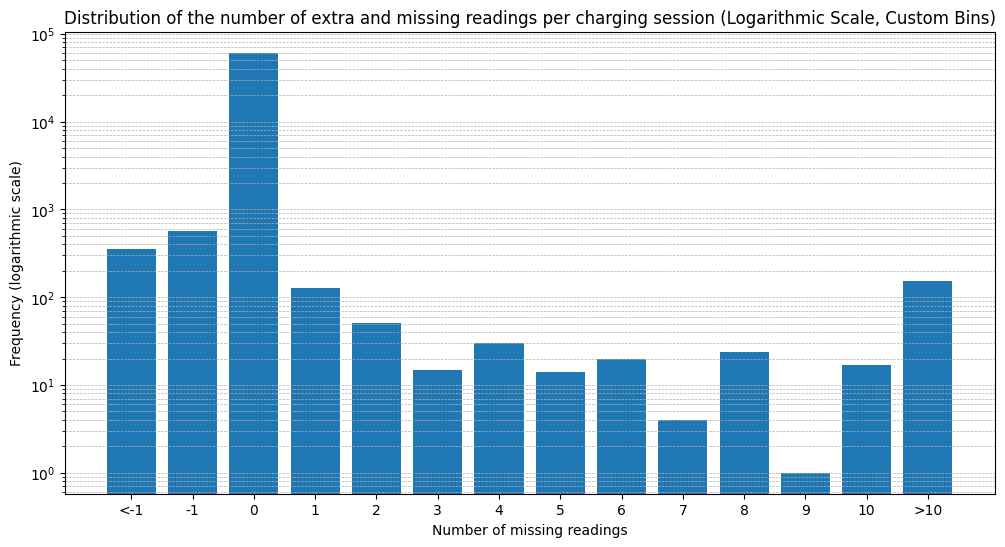

In [12]:
# Calculates the value counts of missing readings per charging session
missing_readings_counts = session_stats['n_missing_readings'].value_counts().sort_index()

# Defines custom histogram bins s.t. the counts <-1 and >10 are binned
binned_counts = {
    '<-1': missing_readings_counts[missing_readings_counts.index < -1].sum(),
    **missing_readings_counts[(missing_readings_counts.index >= -1) & (missing_readings_counts.index <= 10)].to_dict(),
    '>10': missing_readings_counts[missing_readings_counts.index > 10].sum()
}
binned_categories = [str(key) for key in binned_counts.keys()]  # Keys must be strings to avoid plotting TypeError
binned_values = list(binned_counts.values())

# Plot with logarithmic y-axis
plt.figure(figsize=(12, 6))
plt.bar(binned_categories, binned_values, log=True)
plt.title('Distribution of the number of extra and missing readings per charging session (Logarithmic Scale, Custom Bins)')
plt.xlabel('Number of missing readings')
plt.ylabel('Frequency (logarithmic scale)')
plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)
plt.show()



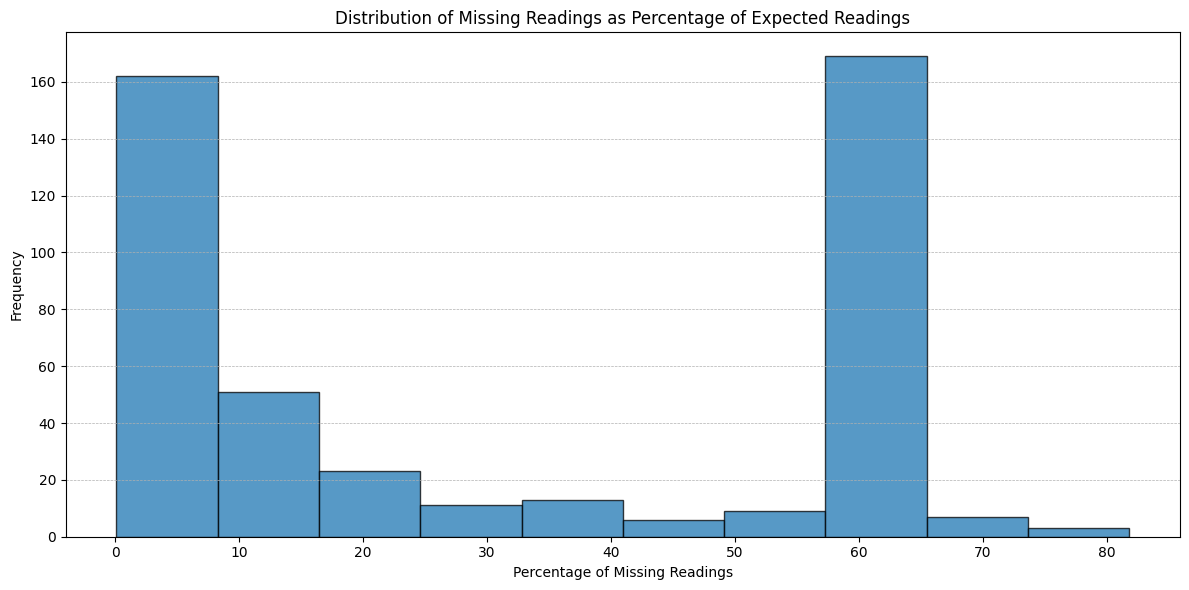

In [13]:
# Filter for sessions with missing readings (negative percentages only)
missing_readings_data = session_stats['extra_or_missing_percentage'][session_stats['extra_or_missing_percentage'] > 0]

# Define more bins for finer granularity
bins = np.linspace(0.1, missing_readings_data.max(), 11)  # 50 bins between the minimum and 0

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.hist(missing_readings_data, bins=bins, alpha=0.75, edgecolor='black')
plt.title('Distribution of Missing Readings as Percentage of Expected Readings')
plt.xlabel('Percentage of Missing Readings')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

##### 2.1.2.2 Handling missing and extra readings
To handle missing and duplicate readings, each session is reindexed to a complete one-minute grid from its first to last minute. Time-dependent numerics (`soc`, `power`, `energy`) use linear interpolation to fill gaps after reindexing. Session-level static fields (`charging_duration`, `charger_category`, `nominal_power`, `temp`) are forward-filled and backward-filled to remain constant within each session.

Charging sessions with excessive missingness are discarded. The threshold uses percentage of expected readings to keep the criterion consistent across variable session lengths.

In [14]:
# Filter sessions based on the threshold of <20% missing readings
threshold = 20
valid_sessions = session_stats[
    session_stats['extra_or_missing_percentage'] <= threshold
]['charging_id']

# Keep only valid sessions in the original dataset
df = df[df['charging_id'].isin(valid_sessions)]
n_remaining_sessions = len(df["charging_id"].unique())

print(f"Total number of charging sessions: {len(session_stats)}")
print(f"Remaining charging sessions after removing {len(session_stats) - n_remaining_sessions} "
      f"sessions with more than 20% missing readings: {n_remaining_sessions}")

Total number of charging sessions: 62393
Remaining charging sessions after removing 230 sessions with more than 20% missing readings: 62163


In [15]:
def resample_and_interpolate_session(session: pd.DataFrame) -> pd.DataFrame:
    """Reindexes one session to a complete one-minute grid and repairs gaps.

    Args:
        session: Rows from one `charging_id` session.

    Returns:
        A reindexed and interpolated session dataframe.
    """
    session = session.sort_values("minutes_elapsed")

    # Collapses duplicate minute stamps before reindexing.
    session = session.groupby("minutes_elapsed", observed=False, as_index=True).agg(
        soc=("soc", "mean"),
        power=("power", "mean"),
        energy=("energy", "mean"),
        charging_duration=("charging_duration", "first"),
        charger_category=("charger_category", "first"),
        nominal_power=("nominal_power", "first"),
        temp=("temp", "first"),
    )

    minute_start = int(session.index.min())
    minute_end = int(session.index.max())
    full_index = pd.Index(range(minute_start, minute_end + 1), name="minutes_elapsed")
    session = session.reindex(full_index)

    numerical_cols = ["soc", "power", "energy"]
    static_cols = ["charging_duration", "charger_category", "nominal_power", "temp"]

    session[numerical_cols] = session[numerical_cols].interpolate(method="linear").ffill().bfill()
    session[static_cols] = session[static_cols].ffill().bfill()

    return session.reset_index()

resampled_sessions = []
for charging_id, session in df.groupby("charging_id", observed=False):
    resampled_session = resample_and_interpolate_session(session)
    resampled_session["charging_id"] = charging_id
    resampled_sessions.append(resampled_session)

resampled_df = pd.concat(resampled_sessions, ignore_index=True)
all_columns = [
    "charging_id", "minutes_elapsed", "power", "soc", "energy",
    "charging_duration", "charger_category", "nominal_power", "temp",
]
df = resampled_df[all_columns]
print("Resampled all sessions to complete one-minute grids.")

Resampled all sessions to complete one-minute grids.


In [16]:
df.isna().sum()

charging_id          0
minutes_elapsed      0
power                0
soc                  0
energy               0
charging_duration    0
charger_category     0
nominal_power        0
temp                 0
dtype: int64

In [17]:
static_vars = ["charging_id", "charging_duration", "charger_category", "nominal_power", "temp"]
df[static_vars] = df[static_vars].bfill()
df.isna().sum()

charging_id          0
minutes_elapsed      0
power                0
soc                  0
energy               0
charging_duration    0
charger_category     0
nominal_power        0
temp                 0
dtype: int64

 ### 2.2 Removing unusually short and long sessions
Charging sessions that are very short lack sufficient temporal information for time series modeling and are disproportionately rare in the dataset. To be specific, short sessions might give a high prediction error, while long, mostly static charging sessions at low power will influence the model to predict a constant value as they contribute disproportionately to the loss calculations.

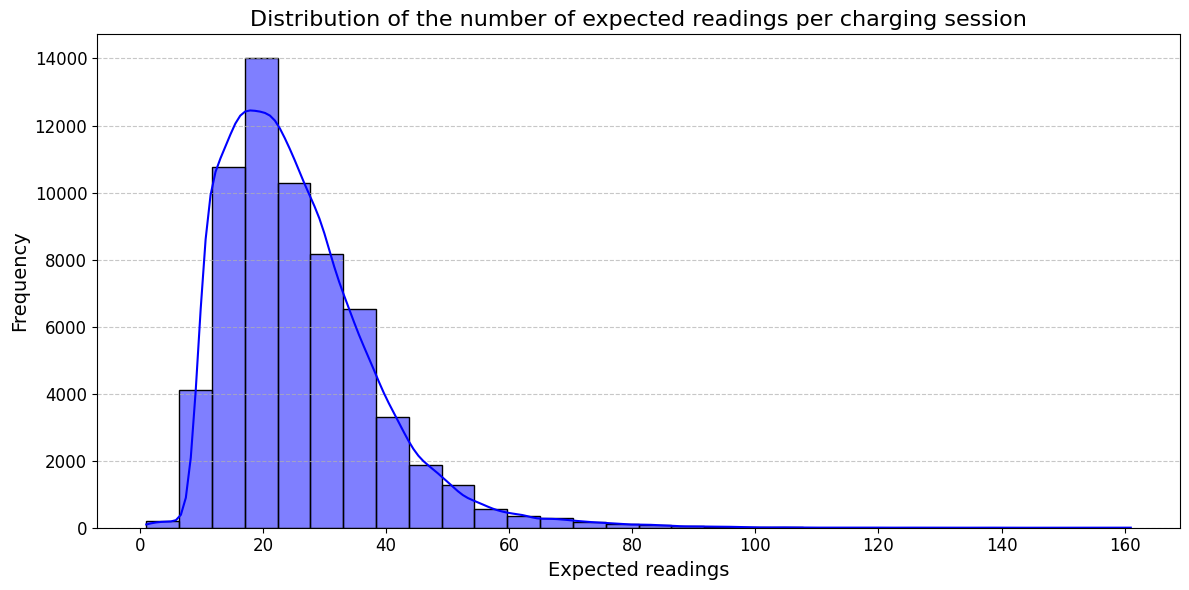

In [18]:
# Re-calculates the session statistics after handling missing data
new_session_stats = calculate_session_stats(df)

# Plots a histogram of the number of expected readings
plt.figure(figsize=(12, 6))
sns.histplot(data=new_session_stats, x='expected_readings', kde=True, bins=30, color='blue', edgecolor='black')
plt.title('Distribution of the number of expected readings per charging session', fontsize=16)
plt.xlabel('Expected readings', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

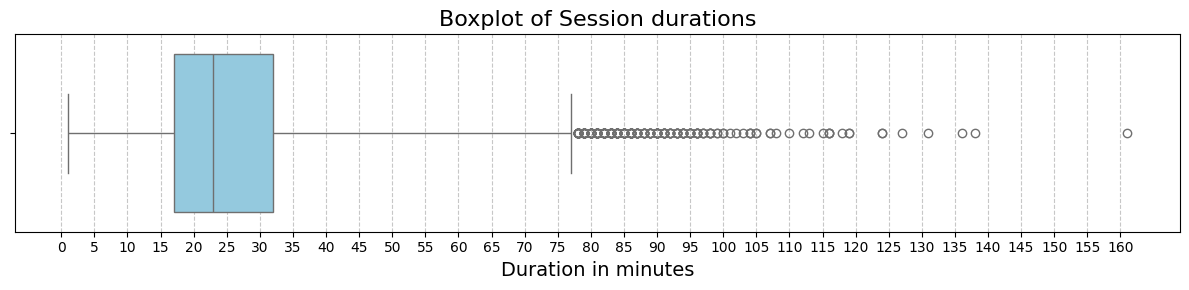

In [19]:
# Boxplot
plt.figure(figsize=(12, 3))
sns.boxplot(x=new_session_stats['expected_readings'], color='skyblue', orient='h', whis=3.0)
plt.title('Boxplot of Session durations', fontsize=16)
plt.xlabel('Duration in minutes', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xticks(np.arange(0, session_stats['expected_readings'].max() + 1, 5), fontsize=10)
plt.show()

In [20]:
short_sessions = new_session_stats[new_session_stats["expected_readings"] < 8]
print(f"Number of charging sessions with an expected duration < 8 minutes: {len(short_sessions)}")
long_sessions = new_session_stats[new_session_stats["expected_readings"] > 60]
print(f"Number of charging sessions with an expected duration > 60 minutes: {len(long_sessions)}")


Number of charging sessions with an expected duration < 8 minutes: 229
Number of charging sessions with an expected duration > 60 minutes: 1019


#### Removing very short charging sessions

In [21]:
short_sessions_ids = short_sessions["charging_id"]
df = df[~df["charging_id"].isin(short_sessions_ids)]
print(f"Removed {len(short_sessions_ids)} short charging sessions from the dataset")

Removed 229 short charging sessions from the dataset


#### Removing very long charging sessions

In [22]:
long_sessions_ids = long_sessions["charging_id"]
df = df[~df["charging_id"].isin(long_sessions_ids)]
print(f"Removed {len(long_sessions_ids)} long charging sessions from the dataset")

Removed 1019 long charging sessions from the dataset


#### Removing the `charging_duration` variable from the dataset
It is apparent that the `charging_duration` values provided don't always match the charging session's duration between the first and the last timesteps. Going forward, we will therefore not be using this variable. 

In [23]:
df = df.drop(columns=["charging_duration"])
all_columns.remove("charging_duration")

## 3 - Feature Engineering
With a clean, consistent minute index we now add features that help the models learn session dynamics: progress, relative power, intra-session deltas and EMAs, charger-category one-hot encoding, and taper-regime indicators.

### 3.1 Adding a progress feature (log-scaled duration)

A compressed timeline helps the model focus early-session dynamics while not over-weighting rare long tails. The mapping uses the existing `minutes_elapsed` index and scales values to `[0, 1]` with a logarithmic transform capped at 120 minutes.

In [24]:
# Progress feature (log-scaled minutes)
df["progress"] = np.log1p(df["minutes_elapsed"]) / np.log1p(120.0)
df["progress"] = np.minimum(df["progress"], 1.0)
df.head()

,charging_id,minutes_elapsed,power,soc,energy,charger_category,nominal_power,temp,progress
0,0,0,89.44,40.0,0.32,Ultra,150.0,4.0,0.000000
1,0,1,92.75,41.0,1.84,Ultra,150.0,4.0,0.144532
2,0,2,94.81,43.0,3.41,Ultra,150.0,4.0,0.229078
3,0,3,95.68,45.0,5.00,Ultra,150.0,4.0,0.289065
4,0,4,96.88,47.0,6.60,Ultra,150.0,4.0,0.335594


### 3.2 Relative power
We normalize instantaneous power by the site’s nominal capacity (clipped to 120% then
rescaled to `[0,1]`).

In [25]:
denom = np.clip(df["nominal_power"].astype(float).values, 1e-6, None)
rel = (df["power"].astype(float).values / denom)
rel = np.clip(rel, 0.0, 1.2)
df["rel_power"] = rel / 1.2
df.head()

,charging_id,minutes_elapsed,power,soc,energy,charger_category,nominal_power,temp,progress,rel_power
0,0,0,89.44,40.0,0.32,Ultra,150.0,4.0,0.000000,0.496889
1,0,1,92.75,41.0,1.84,Ultra,150.0,4.0,0.144532,0.515278
2,0,2,94.81,43.0,3.41,Ultra,150.0,4.0,0.229078,0.526722
3,0,3,95.68,45.0,5.00,Ultra,150.0,4.0,0.289065,0.531556
4,0,4,96.88,47.0,6.60,Ultra,150.0,4.0,0.335594,0.538222


### 3.3 Adding deltas: change in `power` and `SOC` over time
Because we want to train a residual model, we have to calculate the changes (deltas) of the target variables.

In [26]:
df["d_power"] = df.groupby("charging_id", observed=False)["power"].diff().fillna(0.0)
df["d_soc"]   = df.groupby("charging_id", observed=False)["soc"].diff().fillna(0.0)
df.head()

,charging_id,minutes_elapsed,power,soc,energy,charger_category,nominal_power,temp,progress,rel_power,d_power,d_soc
0,0,0,89.44,40.0,0.32,Ultra,150.0,4.0,0.000000,0.496889,0.00,0.0
1,0,1,92.75,41.0,1.84,Ultra,150.0,4.0,0.144532,0.515278,3.31,1.0
2,0,2,94.81,43.0,3.41,Ultra,150.0,4.0,0.229078,0.526722,2.06,2.0
3,0,3,95.68,45.0,5.00,Ultra,150.0,4.0,0.289065,0.531556,0.87,2.0
4,0,4,96.88,47.0,6.60,Ultra,150.0,4.0,0.335594,0.538222,1.20,2.0


### 3.4 EMA per session
We smooth the deltas by applying a short Exponential Moving Average (span=3) within each session. We weight recent values more heavily than older ones, which helps reduce noise while retaining trend information. This in turn lowers the input variance and helps the network learn the underlying change dynamics, leading to improved generalization ability. 

In [27]:
df["d_power_ema3"] = df.groupby("charging_id", observed=False)["d_power"] \
                       .transform(lambda s: s.ewm(span=3, adjust=False).mean()).fillna(0.0)
df["d_soc_ema3"]   = df.groupby("charging_id", observed=False)["d_soc"] \
                       .transform(lambda s: s.ewm(span=3, adjust=False).mean()).fillna(0.0)
df.head()

,charging_id,minutes_elapsed,power,soc,energy,charger_category,nominal_power,temp,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3
0,0,0,89.44,40.0,0.32,Ultra,150.0,4.0,0.000000,0.496889,0.00,0.0,0.000000,0.0000
1,0,1,92.75,41.0,1.84,Ultra,150.0,4.0,0.144532,0.515278,3.31,1.0,1.655000,0.5000
2,0,2,94.81,43.0,3.41,Ultra,150.0,4.0,0.229078,0.526722,2.06,2.0,1.857500,1.2500
3,0,3,95.68,45.0,5.00,Ultra,150.0,4.0,0.289065,0.531556,0.87,2.0,1.363750,1.6250
4,0,4,96.88,47.0,6.60,Ultra,150.0,4.0,0.335594,0.538222,1.20,2.0,1.281875,1.8125


### 3.5 One-hot encoding of charger category
We derive a coarse charger category from `nominal_power` bins (low/mid/high) and one‑hot it as a numerical value.

In [28]:
bins   = [0, 75, 200, np.inf]
labels = ["low", "mid", "high"]
ohe_src = pd.cut(df["nominal_power"].astype(float), bins=bins, labels=labels, include_lowest=True, right=True)
ohe = pd.get_dummies(ohe_src, prefix="charger_cat", dtype=np.float32)

# Ensures all expected one-hot columns are present
for col in ["charger_cat_low", "charger_cat_mid", "charger_cat_high"]:
    if col not in ohe.columns:
        ohe[col] = 0.0
ohe = ohe[["charger_cat_low", "charger_cat_mid", "charger_cat_high"]]

df = pd.concat([df, ohe], axis=1)
print("Added charger category one-hot features.")

Added charger category one-hot features.


### 3.6 Taper regime features

In [29]:
# Adds taper-aware regime features
TAPER_SOC = 71.0  # Manually deduced from EDA taper analysis
df["in_taper"] = (df["soc"] >= TAPER_SOC).astype("float32")
# normalized distance above taper (0 below/at 71, rising toward 1 near 100)
df["dist_to_taper"] = np.clip((df["soc"] - TAPER_SOC) / max(1.0, (df["soc"].max() - TAPER_SOC)), 0.0, 1.0)

### 3.7 Wrap-up and save dataset
The final dataframe keeps a stable column order and is stored as a public, processed parquet file for EDA and modelling notebooks.

In [30]:
ordered_cols = [
    "charging_id",
    "minutes_elapsed", "progress",
    "power", "rel_power", "d_power", "d_power_ema3", "soc", "d_soc", "d_soc_ema3", "energy",
    "nominal_power", "charger_category", "charger_cat_low", "charger_cat_mid", "charger_cat_high",
    "temp", "in_taper", "dist_to_taper",
]
existing_cols = [c for c in ordered_cols if c in df.columns]
rest = [c for c in df.columns if c not in existing_cols]
df = df[existing_cols + rest]

df.to_parquet(OUT_PARQUET, index=False)
print(f"Saved processed public dataset to {OUT_PARQUET}")

Saved processed public dataset to ../Data/etron55-charging-sessions-public-processed.parquet


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1519679 entries, 0 to 1594764
Data columns (total 19 columns):
 #   Column            Non-Null Count    Dtype   
---  ------            --------------    -----   
 0   charging_id       1519679 non-null  int64   
 1   minutes_elapsed   1519679 non-null  int64   
 2   progress          1519679 non-null  float64 
 3   power             1519679 non-null  float64 
 4   rel_power         1519679 non-null  float64 
 5   d_power           1519679 non-null  float64 
 6   d_power_ema3      1519679 non-null  float64 
 7   soc               1519679 non-null  float64 
 8   d_soc             1519679 non-null  float64 
 9   d_soc_ema3        1519679 non-null  float64 
 10  energy            1519679 non-null  float64 
 11  nominal_power     1519679 non-null  float64 
 12  charger_category  1519679 non-null  category
 13  charger_cat_low   1519679 non-null  float32 
 14  charger_cat_mid   1519679 non-null  float32 
 15  charger_cat_high  1519679 non-null  f

In [32]:
# Quick session-level preview of static context
session_preview = (
    df.drop_duplicates(subset="charging_id", keep="first")
    [["charging_id", "temp", "nominal_power", "charger_category"]]
)
print(session_preview.head())

     charging_id  temp  nominal_power charger_category
0              0   4.0          150.0            Ultra
23          4084   7.0          150.0            Ultra
43          9323   4.0          150.0            Ultra
82         11921   5.0          100.0            Rapid
103        17906   6.0          150.0            Ultra


In [33]:
filtered_df = df.groupby('charging_id').filter(lambda x: x['minutes_elapsed'].max() <= 2)
filtered_df

,charging_id,minutes_elapsed,progress,power,rel_power,d_power,d_power_ema3,soc,d_soc,d_soc_ema3,energy,nominal_power,charger_category,charger_cat_low,charger_cat_mid,charger_cat_high,temp,in_taper,dist_to_taper


In [34]:
# Save the final dataframe as a Parquet file
df.to_parquet(OUT_PARQUET, index=False)
print(f"Wrote {len(df):,} processed rows.")

Wrote 1,519,679 processed rows.


In [35]:
df.head()

,charging_id,minutes_elapsed,progress,power,rel_power,d_power,d_power_ema3,soc,d_soc,d_soc_ema3,energy,nominal_power,charger_category,charger_cat_low,charger_cat_mid,charger_cat_high,temp,in_taper,dist_to_taper
0,0,0,0.000000,89.44,0.496889,0.00,0.000000,40.0,0.0,0.0000,0.32,150.0,Ultra,0.0,1.0,0.0,4.0,0.0,0.0
1,0,1,0.144532,92.75,0.515278,3.31,1.655000,41.0,1.0,0.5000,1.84,150.0,Ultra,0.0,1.0,0.0,4.0,0.0,0.0
2,0,2,0.229078,94.81,0.526722,2.06,1.857500,43.0,2.0,1.2500,3.41,150.0,Ultra,0.0,1.0,0.0,4.0,0.0,0.0
3,0,3,0.289065,95.68,0.531556,0.87,1.363750,45.0,2.0,1.6250,5.00,150.0,Ultra,0.0,1.0,0.0,4.0,0.0,0.0
4,0,4,0.335594,96.88,0.538222,1.20,1.281875,47.0,2.0,1.8125,6.60,150.0,Ultra,0.0,1.0,0.0,4.0,0.0,0.0
